# Libraries

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from joblib import dump


# Loading Dataset

In [167]:
df = pd.read_csv('../data/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


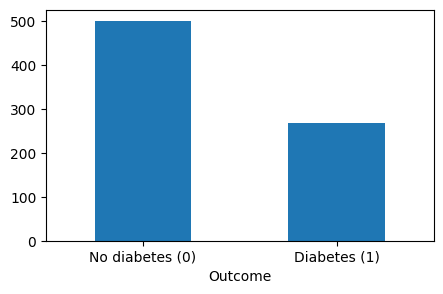

In [168]:
plt.figure(figsize=(5, 3))
df['Outcome'].value_counts().plot(kind='bar')
plt.xticks([0, 1], ['No diabetes (0)', 'Diabetes (1)'], rotation=0)
plt.show()

# Preprocessing

## Handling Zeros as NaN Values

In [169]:
zero_as_nan_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_as_nan_cols] = df[zero_as_nan_cols].replace(0, np.nan)

for col in zero_as_nan_cols:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

## Removing Outliers

In [170]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

outlier_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for col in outlier_cols:
    df = cap_outliers(df, col)

## Cleaning up the Decimals

In [171]:
int_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'Age', 'Outcome']
df[int_cols] = df[int_cols].round().astype(int)

## Split features / target

In [172]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 614  |  Test size: 154


# Models

## Decision Tree

In [173]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.8181818181818182


## AdaBoost

In [174]:
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=1, random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_ada))

Accuracy: 0.8636363636363636


## Logistic Regression

In [175]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


## Linear Discriminant Analysis LDA

In [176]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
y_pred = lda_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


## Random Forest

In [177]:
rf_model = RandomForestClassifier(n_estimators=100)

In [178]:
model = rf_model.fit(X_train, y_train)

In [179]:
y_pred = model.predict(X_test)
print("Accuracy: " ,accuracy_score(y_test,y_pred))

Accuracy:  0.8571428571428571


## SVM

In [180]:
svm_model = SVC(kernel='rbf', C=1.0)

In [181]:
model = svm_model.fit(X_train, y_train)

In [182]:
y_pred = model.predict(X_test)
print("Accuracy: " ,accuracy_score(y_test,y_pred))

Accuracy:  0.8506493506493507


## K-Nearest Neighbors KNN

In [183]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [184]:
k_scores = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())
best_k = np.argmax(k_scores) + 1
print("Best K:", best_k)

Best K: 7


In [185]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)

In [186]:
model = knn_model.fit(X_train_sc, y_train)

In [187]:
y_pred = model.predict(X_test_sc)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.8441558441558441


## Naive Bayes

In [188]:
nb_model = GaussianNB()

In [189]:
model = nb_model.fit(X_train, y_train)

In [190]:
y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.7467532467532467


# Save the models

In [191]:
dump(lr_model,  "../models/logistic_regression.pkl")
dump(lda_model, "../models/linear_discriminant_analysis.pkl")
dump(ada_model, "../models/adaboost.pkl")
dump(rf_model,  "../models/random_forest.pkl")
dump(dt_model,  "../models/decision_tree.pkl")
dump(knn_model, "../models/k_nearest_neighbors.pkl")
dump(nb_model,  "../models/naive_bayes.pkl")
dump(svm_model, "../models/support_vector_machine.pkl")
dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']